In [236]:
from pathlib import Path

import pymc as pm
import pymc_bart as pmb

import pandas as pd
import numpy as np
import matplotlib.pyplot as pp
import arviz as az
import seaborn as sb

In [237]:
pp.style.use('arviz-darkgrid')

#### Phytoplankton Absorption Prediction


In [238]:
data_dir = Path.cwd() / 'data' / '03_transformed'
data_dir.exists()

True

In [239]:
df_log = pd.read_parquet(data_dir / 'df_log.pqt')

In [240]:
aph_subset = df_log.filter(regex='Rrc|aph')

In [241]:
aph_subset.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN


In [247]:
image_save_path = Path.cwd() / 'manuscript' /'figures'
assert image_save_path.exists()

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


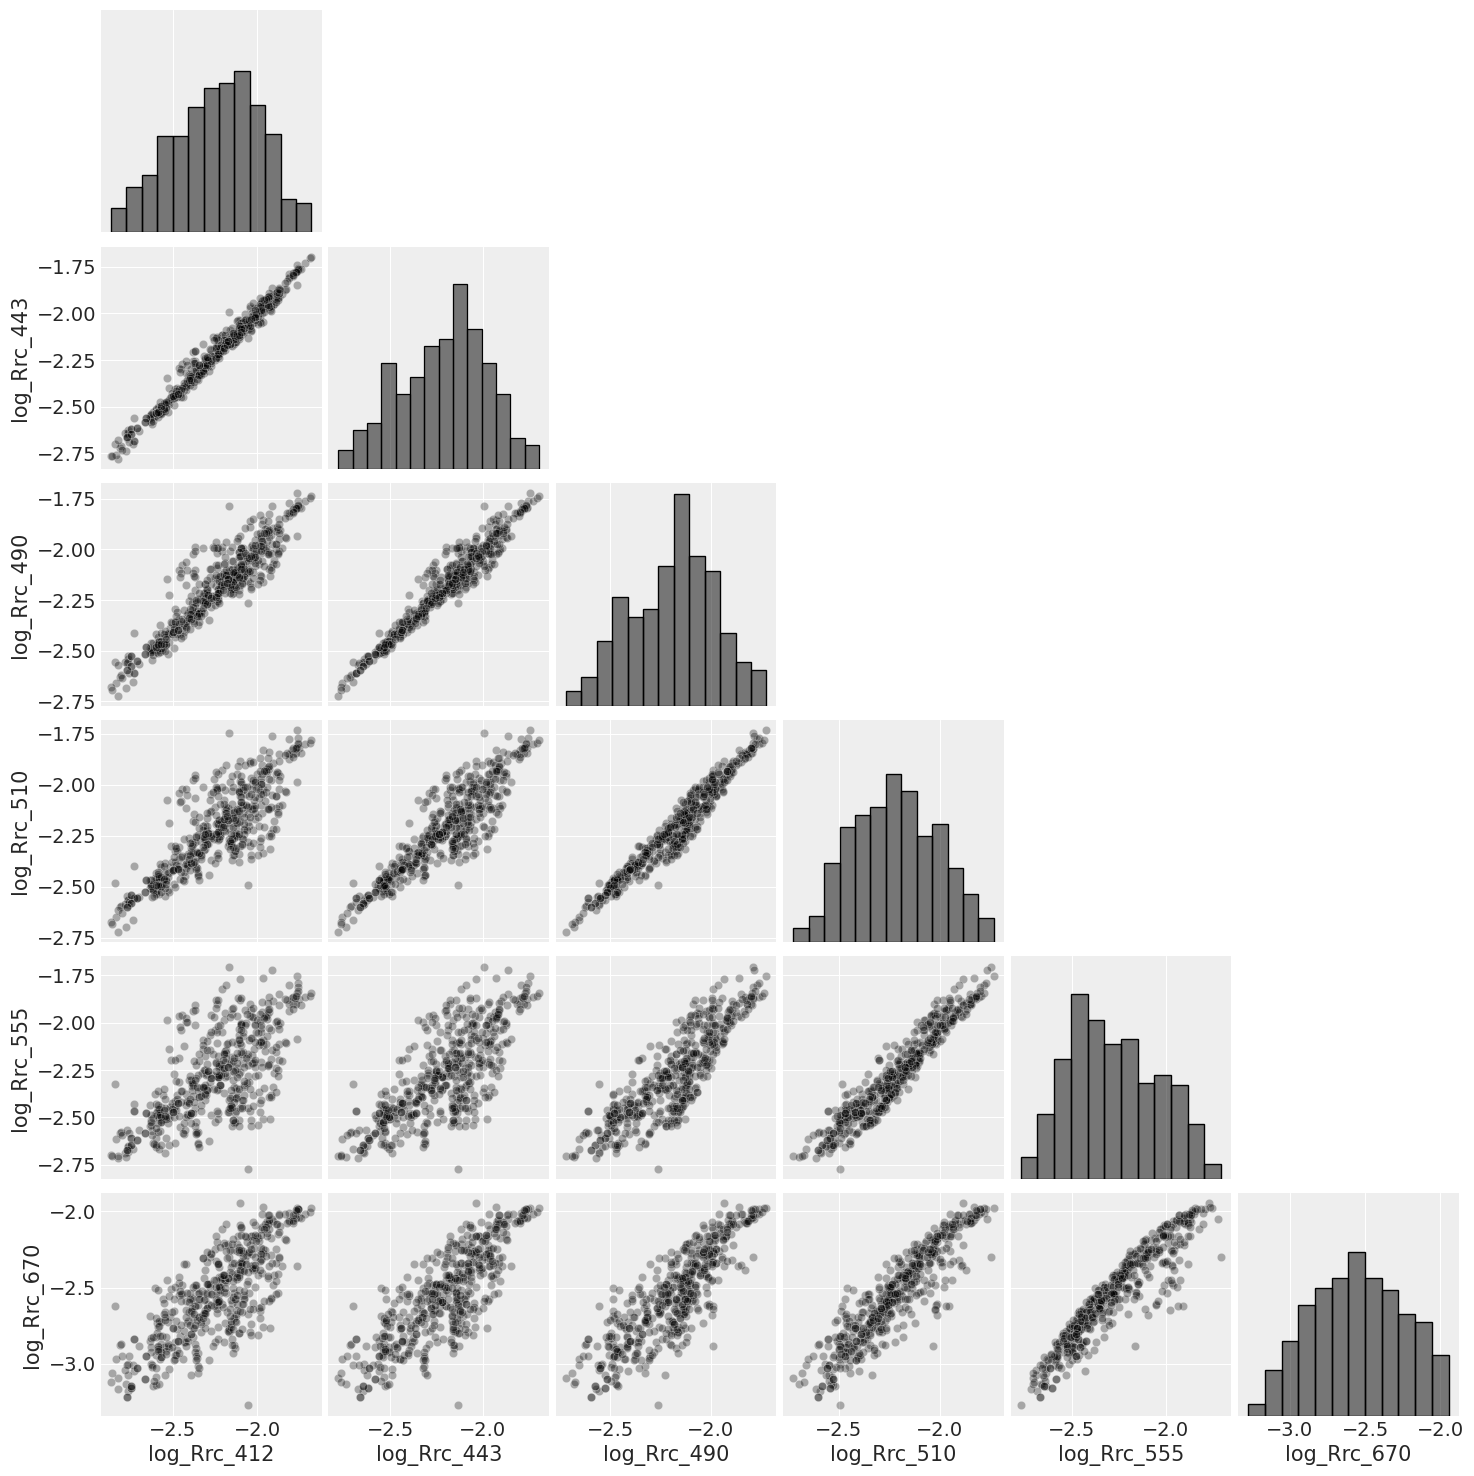

In [249]:
sb.pairplot(aph_subset.filter(
    like='Rrc', axis=1), corner=True, plot_kws = {'color': 'k', 'alpha': 0.3}, 
    diag_kws={'color': 'k', 'alpha': 0.5})
f = pp.gcf()
f.savefig(image_save_path / 'log_rrc_pairplot.png', dpi=300)
f.savefig(image_save_path / 'log_rrc_pairplot.pdf', dpi=300)

In [11]:
aph_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_Rrc_412  494 non-null    float64
 1   log_Rrc_443  494 non-null    float64
 2   log_Rrc_490  494 non-null    float64
 3   log_Rrc_510  494 non-null    float64
 4   log_Rrc_555  494 non-null    float64
 5   log_Rrc_670  494 non-null    float64
 6   log_aph443   168 non-null    float64
 7   log_aph555   165 non-null    float64
 8   log_aph670   168 non-null    float64
dtypes: float64(9)
memory usage: 35.0 KB


In [12]:
X = aph_subset.dropna().filter(regex='Rrc')
Y = aph_subset.dropna().filter(regex='aph')
y = aph_subset.dropna().log_aph443

<Axes: ylabel='Count'>

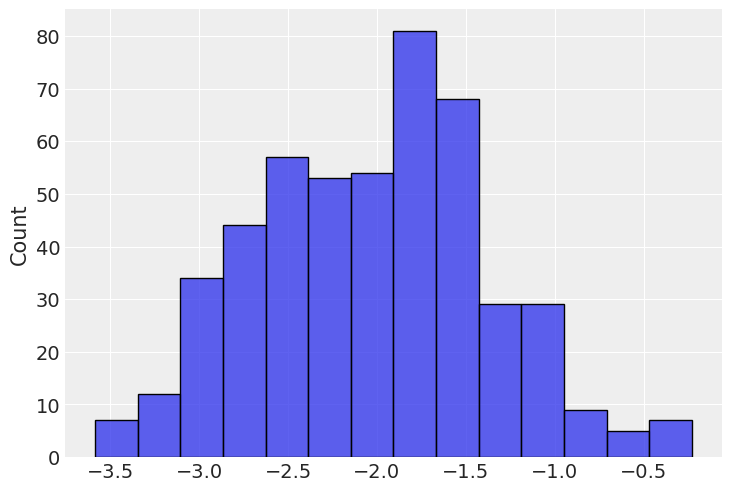

In [187]:
sb.histplot(Y.values.flatten())

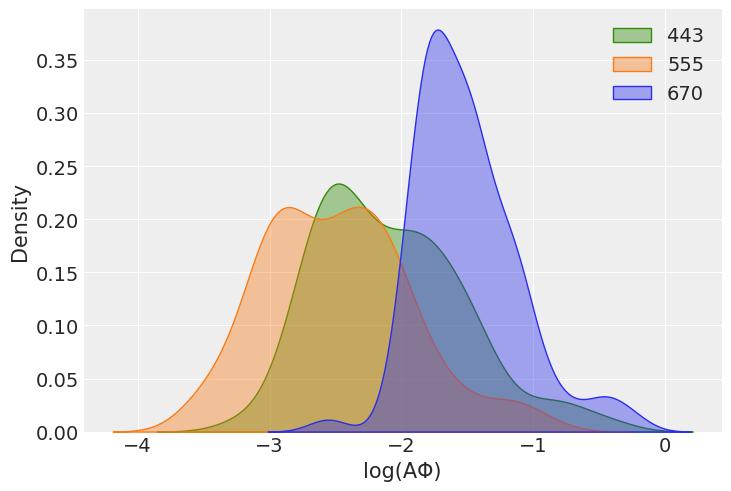

In [354]:
ax = sb.kdeplot(aph_subset.dropna().filter(regex='aph'), fill=True, alpha=0.4, legend=False)
ax.legend(['443', '555', '670'])
ax.set_xlabel('log(AΦ)')
f = pp.gcf()
f.savefig(image_save_path / 'aph_dist.png', dpi=300)
f.savefig(image_save_path / 'aph_dist.pdf', dpi=300)

## Modeling

### Modeling Preparation

In [298]:
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ, 
    'λ_aφ' : λ_aph
}

In [450]:
coords

{'obs_idx': Index([  2,   3,  26,  31,  32,  33,  35,  40,  41,  42,
        ...
        480, 481, 485, 486, 487, 488, 489, 490, 492, 494],
       dtype='int64', length=163),
 'λ_toa': ['412', '443', '490', '510', '555', '670'],
 'λ_aφ': ['443', '555', '670']}

In [299]:
def plot_regression_hdi(idata):
    y_hat_94 = az.hdi(
        idata.posterior_predictive.likelihood).likelihood.to_numpy()
    y_hat_63 = az.hdi(
        idata.posterior_predictive.likelihood, hdi_prob=0.63).likelihood.to_numpy()
    y = idata.observed_data.likelihood.to_numpy()
    x = np.arange(y.size)
    idx = np.argsort(y)

    f, ax = pp.subplots(figsize=(12, 8))
    ax.fill_between(x=x, y1 = y_hat_94[idx, 0], y2=y_hat_94[idx, 1], color='black', label='94% HDI')
    ax.fill_between(x=x, y1=y_hat_63[idx, 0], y2=y_hat_63[idx, 1 ], color='darkgray', label='63% HDI')
    ax.scatter(x, y[idx], s=30, color='red', label='observed')
    ax.legend()
    ax.set_xlabel('observation #')
    ax.set_ylabel(r'$a_φ(443)$')
    return f, ax


### Aφ Model 1 - BART

This is a first stab at predicting Phytoplankton absorption at all 3 wavelengths

In [ ]:
with pm.Model(coords=coords) as m_aph:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ = pm.HalfNormal('σ', 0.5, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, shape=(3, 163)).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

In [355]:
g = m_aph.to_graphviz()

In [ ]:
g.render('bart_model1', directory=image_save_path, view=True, format='png', )

'/Users/erdemkarakoylu/projex/bayesian_TOA_2_IOP/manuscript/figures/bart_model1.png'

In [302]:
with m_aph:
    idata_aph = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ]


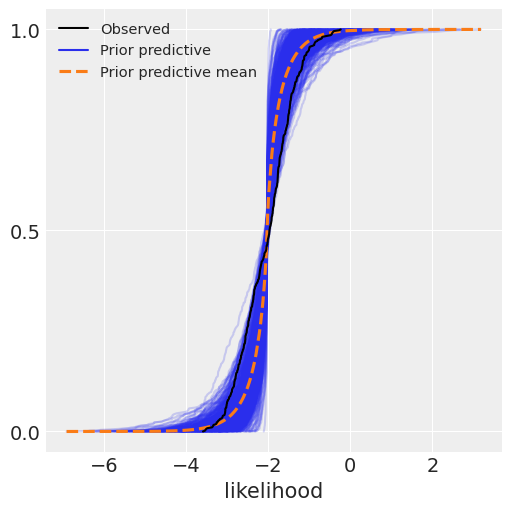

In [303]:
f, ax = pp.subplots(figsize=(5, 5))
ax= az.plot_ppc(idata_aph, group='prior', observed=True, kind='cumulative', ax=ax)

In [304]:
with m_aph:
    idata_aph.extend(pm.sample(draws=2000, chains=4, target_accept=0.95))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


#### Sampling diagnostics

<Axes: >

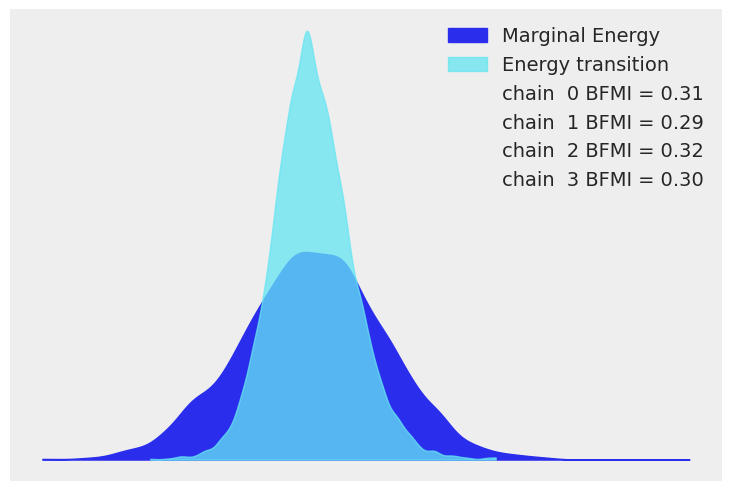

In [305]:
az.plot_energy(idata_aph)

In [306]:
az.summary(idata_aph, kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"μ[0, 0]",0.004,0.002,1225.0,1755.0,1.01
"μ[0, 1]",0.004,0.002,1189.0,1996.0,1.01
"μ[0, 2]",0.005,0.003,998.0,1693.0,1.00
"μ[0, 3]",0.005,0.003,988.0,1490.0,1.00
"μ[0, 4]",0.004,0.003,1057.0,1818.0,1.01
...,...,...,...,...,...
"μ[2, 161]",0.005,0.003,1012.0,1796.0,1.01
"μ[2, 162]",0.005,0.003,1044.0,1889.0,1.00
σ[443],0.001,0.000,1538.0,2918.0,1.00
σ[555],0.001,0.001,1474.0,2645.0,1.00


Text(0.5, 0, '$\\hat{R}$')

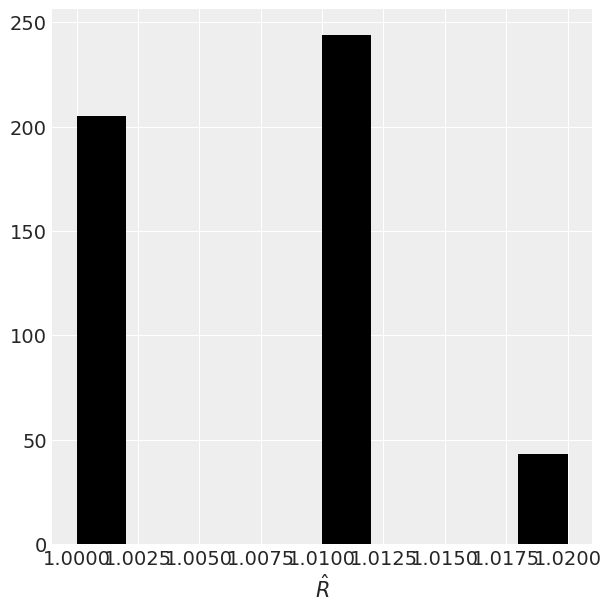

In [489]:
f, ax = pp.subplots(figsize=(6, 6))
az.summary(idata_aph, kind='diagnostics').r_hat.hist(ax=ax, color='k')
ax.set_xlabel(r'$\hat{R}$')

Text(0.5, 0, '$ESS_{tail}$')

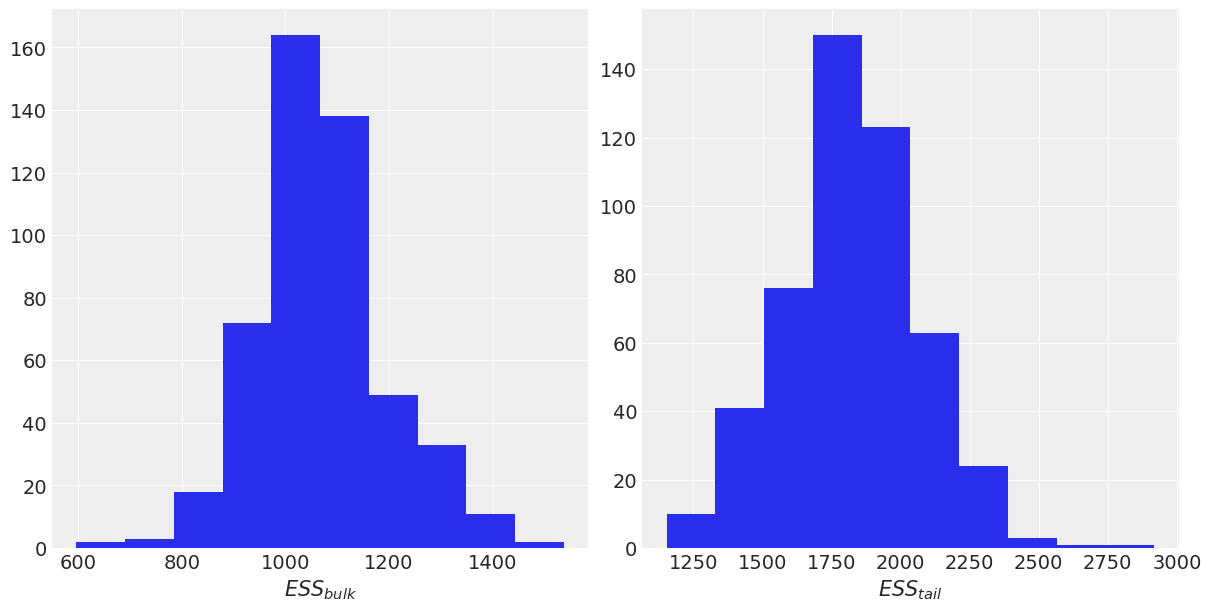

In [ ]:
f, axs = pp.subplots(ncols=2, figsize=(12, 6))
az.summary(idata_aph, kind='diagnostics').ess_bulk.hist(ax=axs[0], color='lightgray')
az.summary(idata_aph, kind='diagnostics').ess_tail.hist(ax=axs[1], color='lightgray')
axs[0].set_xlabel(r'$ESS_{bulk}$')
axs[1].set_xlabel(r'$ESS_{tail}$')

diagnostics mostly OK

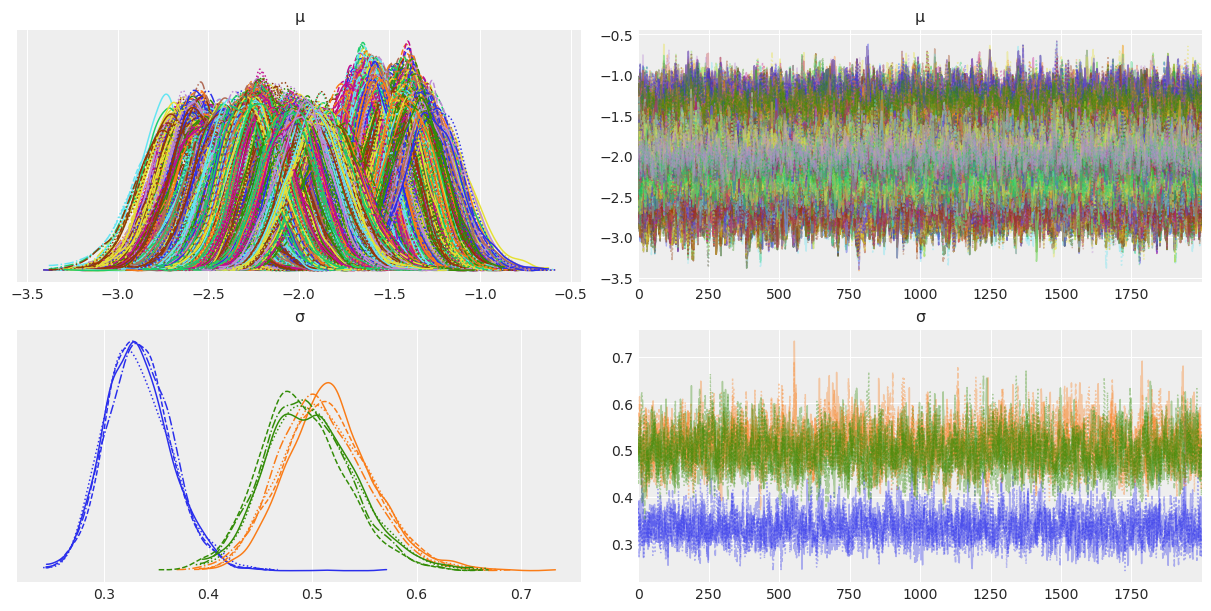

In [309]:
axs = az.plot_trace(idata_aph, figsize=(12, 6))
f = pp.gcf()
f.savefig(image_save_path / 'm1_bart_trace.png', dpi=300)
f.savefig(image_save_path / 'm1_bart_trace.pdf', dpi=300)

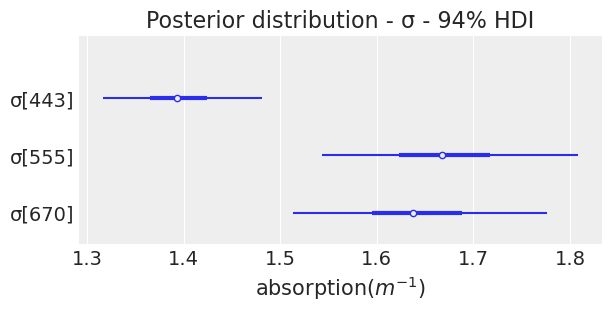

In [310]:
f, ax = pp.subplots(figsize=(6, 3))
az.plot_forest(idata_aph, var_names='σ', ax=ax, combined=True, transform=np.exp)
ax.set_yticklabels(['σ[670]', 'σ[555]', 'σ[443]']);
ax.set_title('Posterior distribution - σ - 94% HDI')
ax.set_xlabel(r'absorption($m^{-1}$)')
f.savefig(image_save_path / 'm1_σ_forest.png', dpi=300)
f.savefig(image_save_path / 'm1_σ_forest.pdf', dpi=300)

In [311]:
with m_aph:
    idata_aph.extend(pm.sample_posterior_predictive(idata_aph))

Sampling: [likelihood]


Output()

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/1813936715.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model1_prior_posterior_pc.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/1813936715.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model1_prior_posterior_pc.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


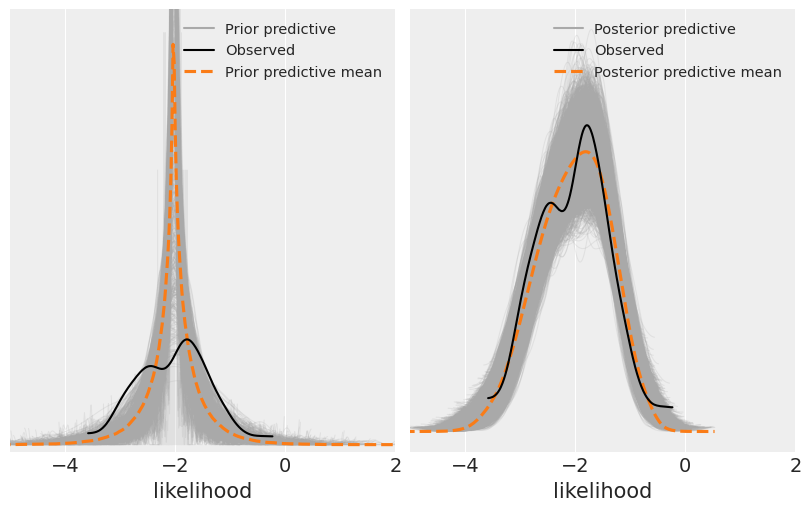

In [488]:
f, ax= pp.subplots(ncols=2, figsize=(8, 5), sharex=True)
az.plot_ppc(idata_aph, group='prior', observed=True, ax=ax[0], colors=['darkgray', 'k', 'C1'])
az.plot_ppc(idata_aph, ax=ax[1], colors=['darkgray', 'k', 'C1'])
ax[0].set_xlim(-5, 3)
ax[1].set_xlim(-5, 2)
y_lims = ax[1].get_ylim()
ax[0].set_ylim(y_lims[0], y_lims[1]* 3)
f.savefig(image_save_path / 'model1_prior_posterior_pc.png', dpi=300)
f.savefig(image_save_path / 'model1_prior_posterior_pc.pdf', dpi=300)

In [ ]:
ax[0].get_ylim()[0]

(-8.481667372597245, 5.0)

In [483]:
ax[1].get_ylim(), ax[0].get_ylim()

((-0.040450725576013175, 0.8494652370962766), (-0.04, 10.0))

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/3233063039.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_ppc_all.png', dpi=300)


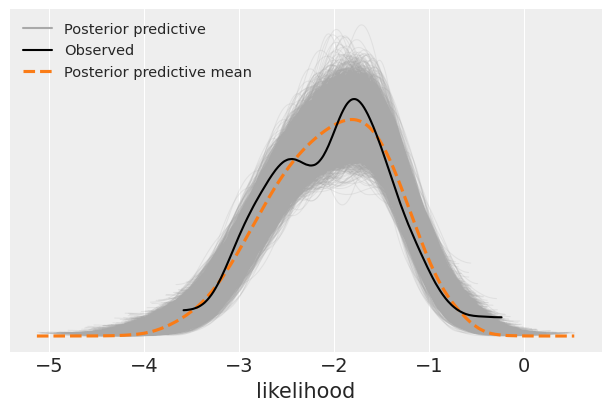

In [312]:
f, ax = pp.subplots(figsize=(6, 4))
az.plot_ppc(idata_aph, colors=['darkgray', 'k', 'C1'], ax=ax)
f.savefig(image_save_path / 'm1_ppc_all.png', dpi=300)
f.savefig(image_save_path / 'm1_ppc_all.pdf', dpi=300)

In [359]:
def plot_3_way_ppc(idata, colors=['darkgray', 'k', 'C1'], kind='kde', include_all=True):
    if include_all:
        f, axs = pp.subplots(ncols=2, nrows=2, figsize=(8, 8), sharex=True, sharey=True)
        ax = axs.ravel()[-1]
        ax.set_title('All targets')
        az.plot_ppc(idata, ax=axs.ravel()[-1], colors=colors, kind=kind)
        ax.set_xlabel(f'log(aφ)')
    else:
        f, axs= pp.subplots(ncols=3, figsize=(13, 4), sharex=True, sharey=True)
    bands = ['443', '555', '670']
    for i, (ax, band) in enumerate(zip(axs.ravel(), bands)):
        az.plot_ppc(
            idata, coords={'λ_aφ': band }, ax=ax, colors=colors, kind=kind)
        ax.set_title(f'λ = {band}')
        if i==2:
            ax.set_xlabel(f'log(aφ)')
    return f, ax

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/2763551147.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/2763551147.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


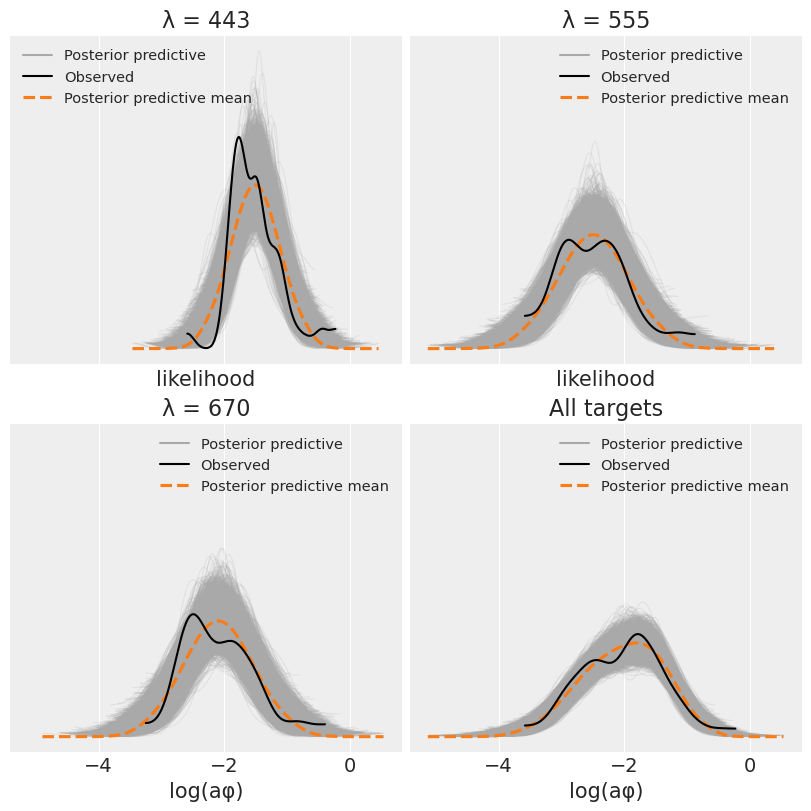

In [327]:
f, ax = plot_3_way_ppc(idata_aph, include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc.pdf', dpi=300)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/4078440884.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/4078440884.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


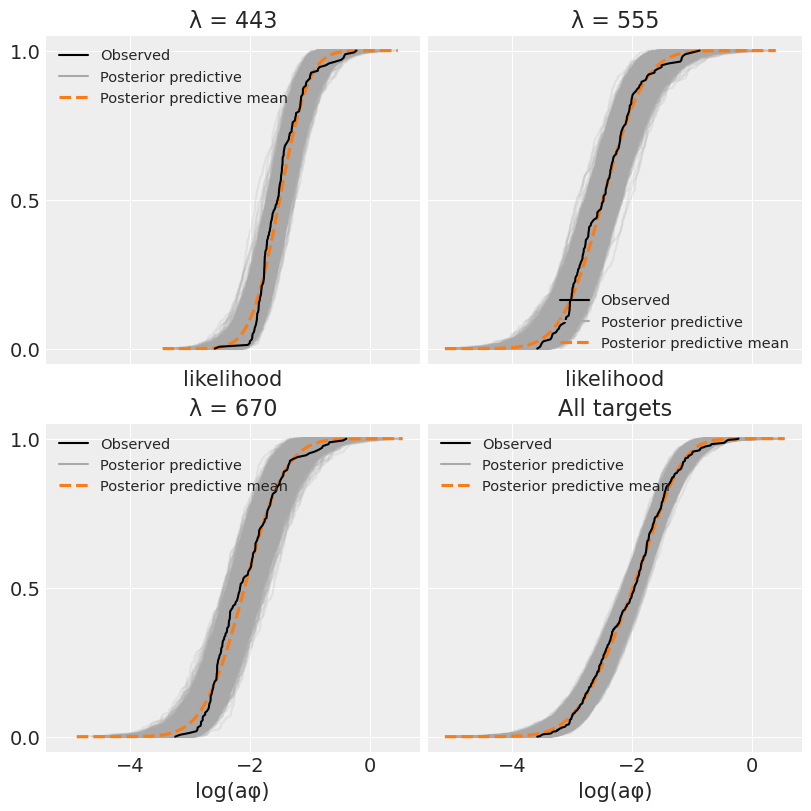

In [328]:
f, ax = plot_3_way_ppc(idata_aph, kind='cumulative', include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [134]:
X_data.eval()[...,None].shape, Y_data.eval().shape

((163, 6, 1), (163, 3))

In [ ]:
with pm.Model(coords=coords) as m_lin_zsn:
    X_data = pm.Data(
        'X_s', X, 
        #StandardScaler().fit_transform(X), 
        dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data(
        'Y_s', Y, 
        #StandardScaler().fit_transform(Y), 
        dims=['obs_idx', 'λ_aφ'])    #α = pm.ZeroSumNormal('α', n_zerosum_axes=1, dims='λ_aφ')
    α = pm.Normal('α', dims='λ_aφ')
    β = pm.ZeroSumNormal('β', dims=['λ_aφ', 'λ_toa'])
    μ =  X_data @ β.T + α
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])


In [364]:
g = m_lin_zsn.to_graphviz()
g.render(filename='m2_graph', directory=image_save_path, format='png')
g.render(filename='m2_graph', directory=image_save_path, format='pdf')

'/Users/erdemkarakoylu/projex/bayesian_TOA_2_IOP/manuscript/figures/m2_graph.pdf'

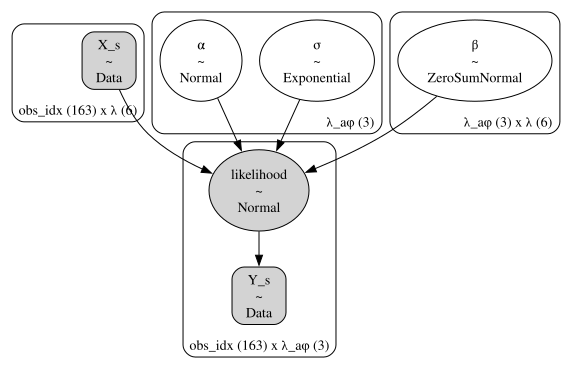

In [363]:
g

In [337]:
with m_lin_zsn:
    idata_lin_zsn = pm.sample_prior_predictive()

Sampling: [likelihood, α, β, σ]


In [339]:
with m_lin_zsn:
    idata_lin_zsn.extend(pm.sample(draws=2000, chains=4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


In [340]:
az.summary(idata_lin_zsn)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[443],-1.300,0.046,-1.388,-1.214,0.000,0.001,9595.0,5869.0,1.0
α[555],-2.173,0.069,-2.306,-2.045,0.001,0.001,10121.0,6797.0,1.0
α[670],-1.754,0.068,-1.882,-1.624,0.001,0.001,10263.0,6225.0,1.0
"β[443, 0]",0.501,0.521,-0.482,1.483,0.006,0.006,8215.0,5596.0,1.0
"β[443, 1]",-1.136,0.765,-2.577,0.274,0.009,0.009,8063.0,5265.0,1.0
"β[443, 2]",-1.970,0.724,-3.275,-0.539,0.008,0.008,8760.0,5796.0,1.0
"β[443, 3]",0.402,0.726,-0.969,1.741,0.008,0.008,7464.0,5564.0,1.0
"β[443, 4]",2.432,0.465,1.590,3.326,0.005,0.005,7939.0,5633.0,1.0
"β[443, 5]",-0.230,0.213,-0.626,0.177,0.002,0.003,8629.0,5235.0,1.0
"β[555, 0]",-0.290,0.592,-1.407,0.822,0.006,0.007,8636.0,6293.0,1.0


array([[<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>]],
      dtype=object)

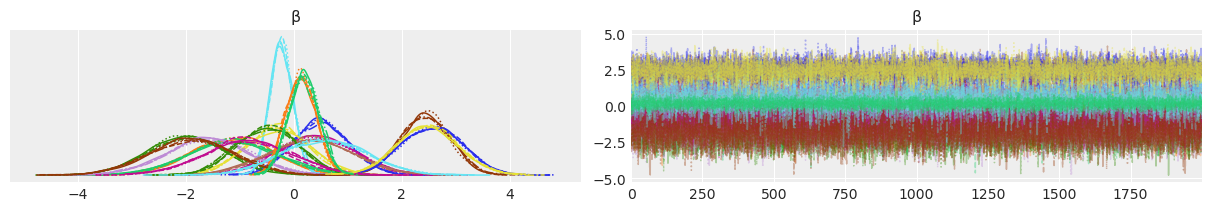

In [341]:
az.plot_trace(idata_lin_zsn,var_names='β')

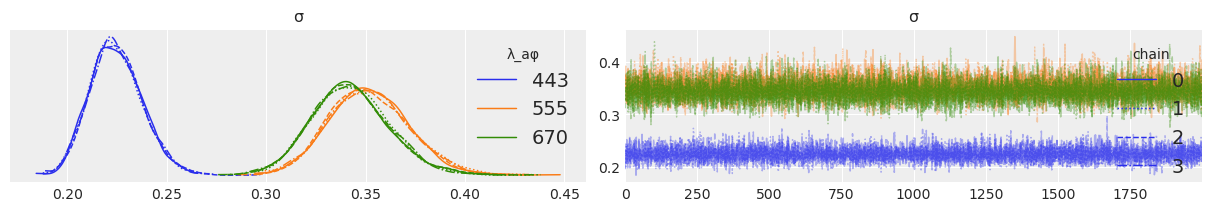

In [342]:
axs = az.plot_trace(idata_lin_zsn, var_names='σ', legend=True).flatten()
#axs[0].legend(['443', '555', '670'])

In [344]:
with m_lin_zsn:
    idata_lin_zsn.extend(pm.sample_posterior_predictive(idata_lin_zsn))

Sampling: [likelihood]


Output()

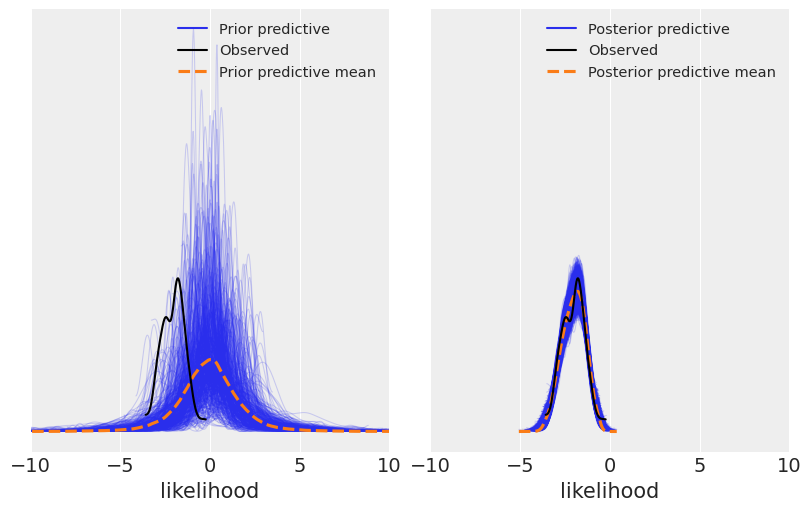

In [365]:
f, ax= pp.subplots(ncols=2, figsize=(8, 5), sharey=True, sharex=True)
az.plot_ppc(idata_lin_zsn, group='prior', observed=True, ax=ax[0])
az.plot_ppc(idata_lin_zsn, ax=ax[1])
ax[0].set_xlim(-10, 10)
ax[1].set_xlim(-10, 10)
f.savefig(image_save_path / 'model2_prior_posterior_pc.png', dpi=300)
f.savefig(image_save_path / 'model2_prior_posterior_pc.pdf', dpi=300)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/3394084552.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm2_3_way_ppc.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/3394084552.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm2_3_way_ppc.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


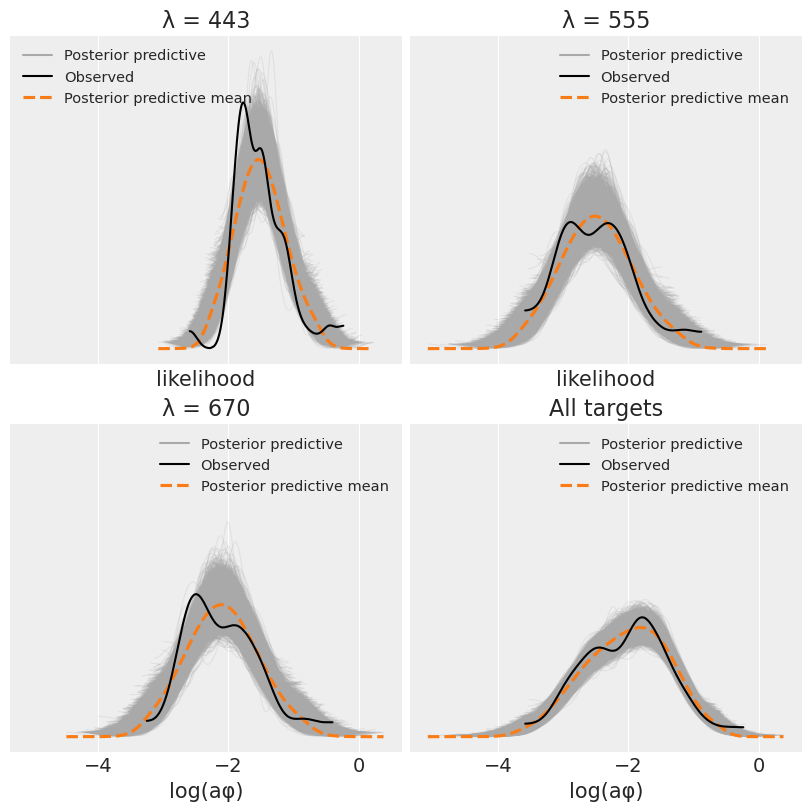

In [347]:
f, ax = plot_3_way_ppc(idata_lin_zsn, include_all=True)
f.savefig(image_save_path / 'm2_3_way_ppc.png', dpi=300)
f.savefig(image_save_path / 'm2_3_way_ppc.pdf', dpi=300)

In [467]:
with pm.Model(coords=coords) as m_hl_zsn:
    X_data = pm.Data(
        'X', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data(
        'Y', Y, dims=['obs_idx', 'λ_aφ'])    #α = pm.ZeroSumNormal('α', n_zerosum_axes=1, dims='λ_aφ')
    
   # Hyperpriors
    #h_α_μ = pm.Normal('h_α_μ', 0, 1)
    #h_α_σ = pm.Gamma('h_α_σ', 2, 2)
    τ = pm.Exponential('τ', 1)

    # Non-centered α
    #α_raw = pm.Normal('α_raw', mu=0, sigma=1, dims='λ_aφ')
    #α = pm.Deterministic('α', h_α_μ + α_raw * h_α_σ)
    α = pm.Normal('α', dims='λ_aφ')
    β = pm.ZeroSumNormal('β', sigma=τ, n_zerosum_axes=2, dims=['λ_toa', 'λ_aφ'])
    μ =  X_data @ β + α
    σ = pm.Gamma('σ', 2, 2, dims='λ_aφ')
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

<Axes: >

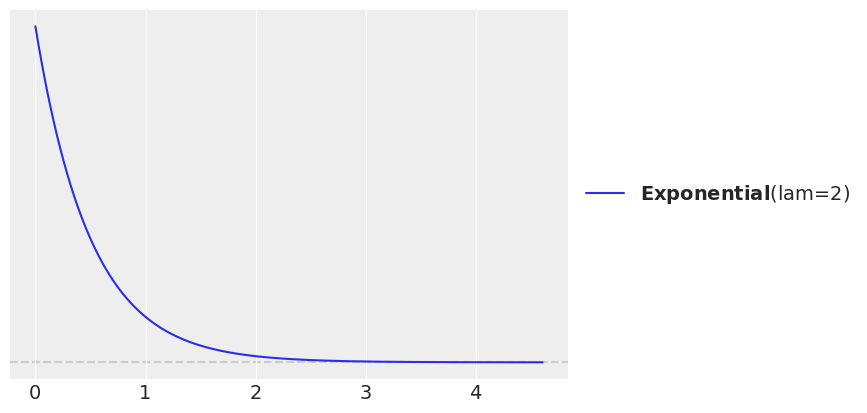

In [466]:
import preliz as pz
pz.Exponential(2).plot_pdf()

In [468]:
g3 = m_hl_zsn.to_graphviz()
g3.render('m3_graph', directory=image_save_path, format='png')
g3.render('m3_graph', directory=image_save_path, format='pdf')

'/Users/erdemkarakoylu/projex/bayesian_TOA_2_IOP/manuscript/figures/m3_graph.pdf'

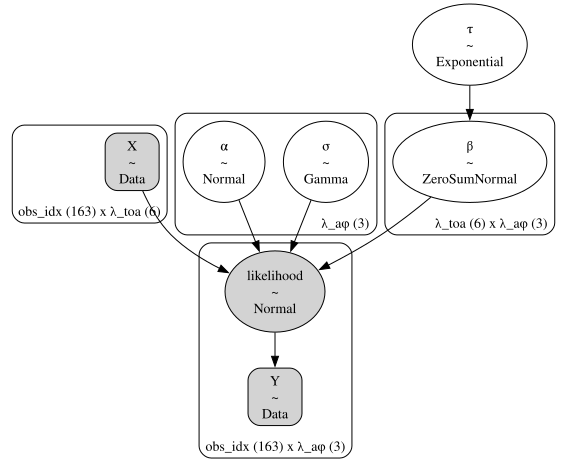

In [469]:
g3

In [470]:
with m_hl_zsn:
    idata_hl_zsn = pm.sample_prior_predictive()

Sampling: [likelihood, α, β, σ, τ]


In [471]:
with m_hl_zsn:
    idata_hl_zsn.extend(pm.sample(draws=2000, chains=4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [τ, α, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [472]:
az.summary(idata_hl_zsn)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[443],-1.348,0.049,-1.442,-1.257,0.001,0.001,6553.0,5327.0,1.00
α[555],-2.562,0.284,-2.996,-2.166,0.134,0.001,6.0,104.0,1.73
α[670],-2.141,0.285,-2.570,-1.748,0.135,0.001,6.0,112.0,1.73
τ,3.515,1.107,1.646,5.558,0.136,0.021,69.0,1639.0,1.04
"β[412, 443]",1.433,0.936,-0.355,3.153,0.067,0.010,196.0,4248.0,1.02
"β[412, 555]",-0.363,1.407,-3.184,2.095,0.352,0.018,16.0,135.0,1.17
"β[412, 670]",-1.069,1.341,-3.613,1.401,0.259,0.020,27.0,213.0,1.09
"β[443, 443]",-1.716,1.544,-4.757,1.123,0.092,0.018,293.0,3747.0,1.02
"β[443, 555]",-0.033,2.156,-3.953,4.106,0.416,0.030,26.0,268.0,1.10
"β[443, 670]",1.749,2.088,-2.185,5.617,0.251,0.030,66.0,3179.0,1.04


array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'τ'}>, <Axes: title={'center': 'τ'}>],
       [<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>]],
      dtype=object)

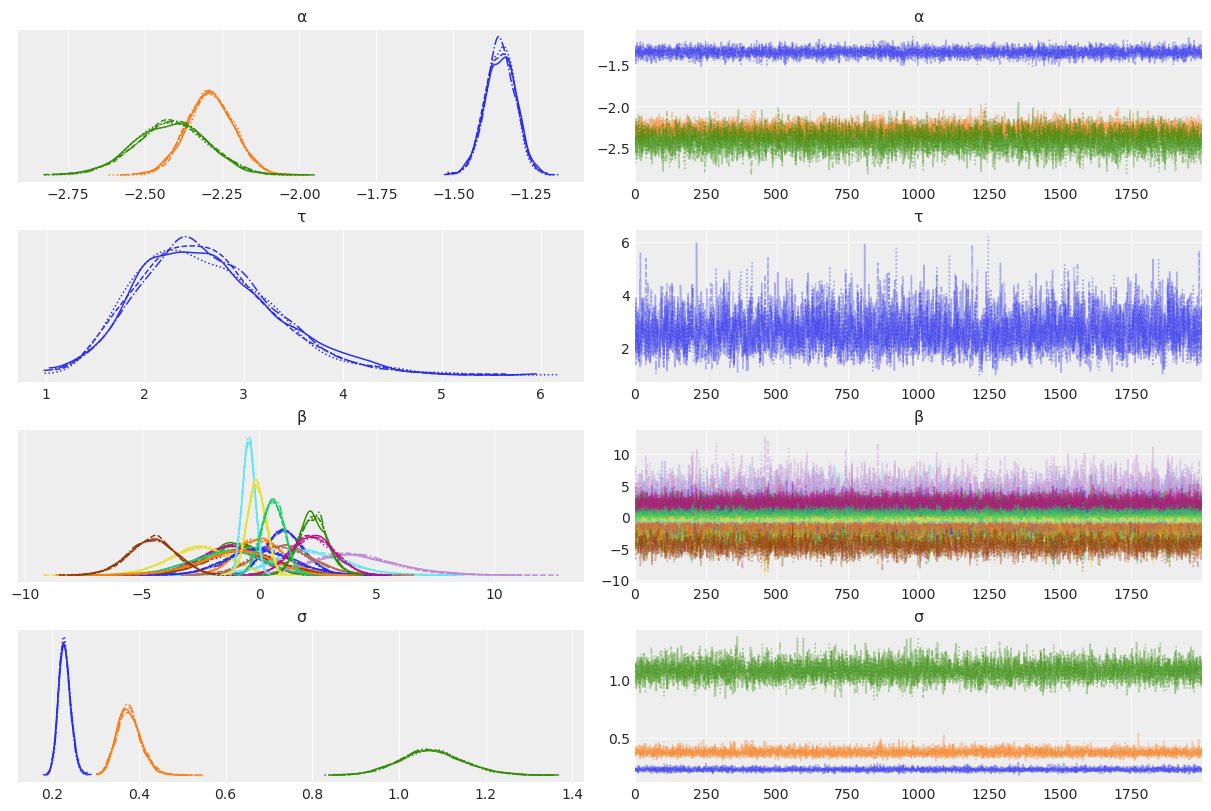

In [446]:
az.plot_trace(idata_hl_zsn)

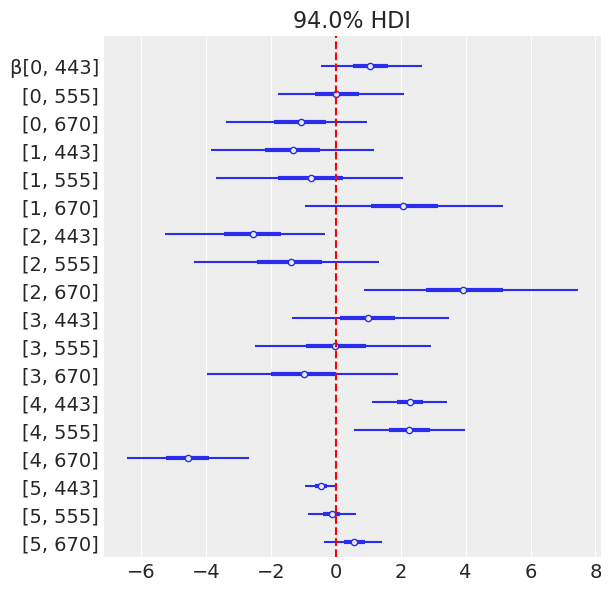

In [449]:
ax = az.plot_forest(idata_hl_zsn, var_names='β', combined=True)[0]
ax.axvline(x=0, color='r', ls='--')

In [408]:
with m_hl_zsn:
    idata_hl_zsn.extend(pm.sample_posterior_predictive(idata_hl_zsn))

Sampling: [likelihood]


Output()

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/4057060808.py:6: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model3_prior_posterior_pc.png', dpi=300)


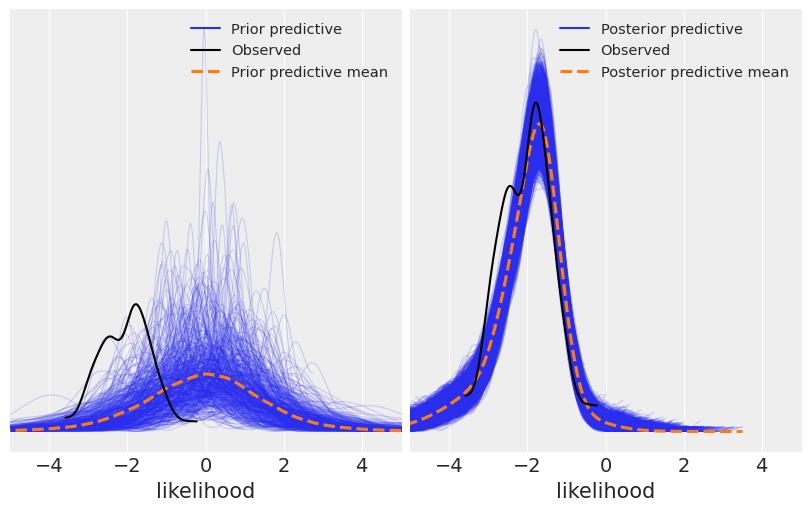

In [409]:
f, ax= pp.subplots(ncols=2, figsize=(8, 5), sharex=True)
az.plot_ppc(idata_hl_zsn, group='prior', observed=True, ax=ax[0])
az.plot_ppc(idata_hl_zsn, ax=ax[1])
ax[0].set_xlim(-5, 5)
ax[1].set_xlim(-5, 5)
f.savefig(image_save_path / 'model3_prior_posterior_pc.png', dpi=300)
f.savefig(image_save_path / 'model3_prior_posterior_pc.pdf', dpi=300)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/1509971764.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model3_3_way_ppc.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_92459/1509971764.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model3_3_way_ppc.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


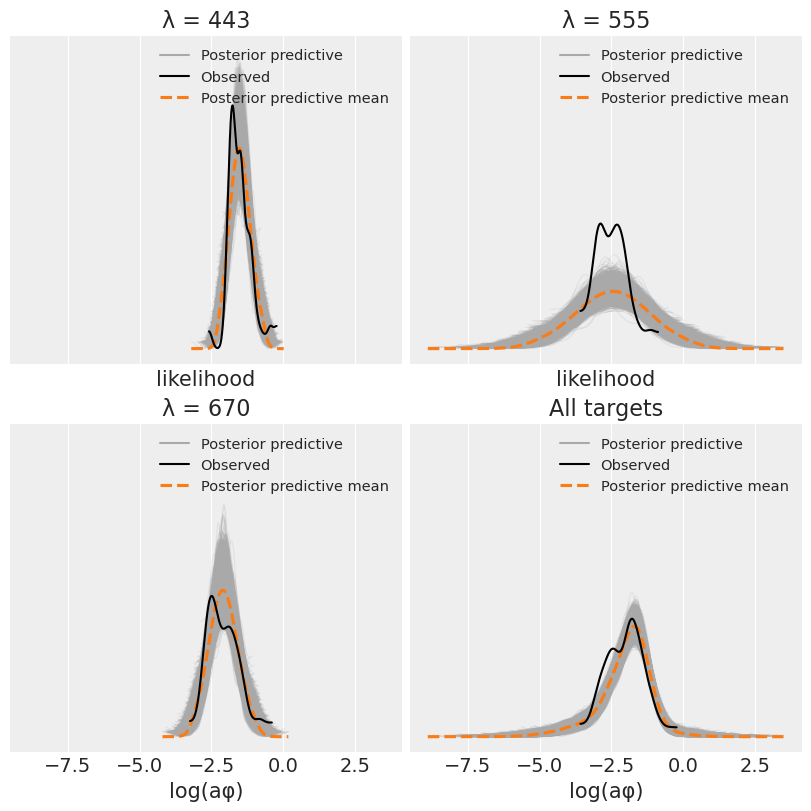

In [410]:
f, ax = plot_3_way_ppc(idata_hl_zsn, include_all=True)
f.savefig(image_save_path / 'model3_3_way_ppc.png', dpi=300)
f.savefig(image_save_path / 'model3_3_way_ppc.pdf', dpi=300)

## Model Comparison

In [411]:
with m_aph:
    try:
        _ = pm.compute_log_likelihood(idata_aph, extend_inferencedata=True)
    except ValueError:
        pass

with m_lin_zsn:
    try:
        _ = pm.compute_log_likelihood(idata_lin_zsn, extend_inferencedata=True)
    except ValueError:
        pass

with m_hl_zsn:
    try:
        _ = pm.compute_log_likelihood(idata_hl_zsn, extend_inferencedata=True)
    except ValueError:
        pass

Output()

Output()

Output()

In [412]:
model_comparison_df = az.compare(
    {
        'model 1': idata_aph,
        'model 2': idata_lin_zsn,
        'model 3': idata_hl_zsn
     }
)
model_comparison_df.round(2)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model 2,0,-111.48,14.87,0.00,0.99,18.15,0.00,False,log
model 3,1,-306.22,15.61,194.75,0.01,22.96,17.99,False,log
model 1,2,-325.58,62.36,214.10,0.00,20.43,14.59,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

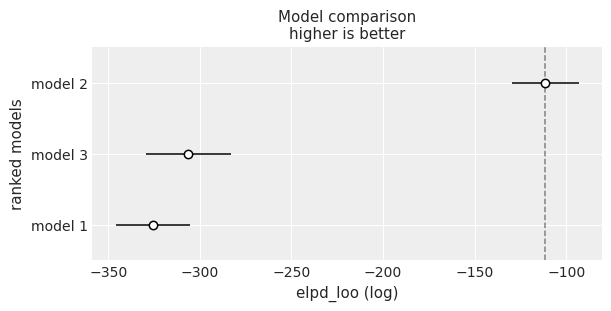

In [413]:
f, ax = pp.subplots(figsize=(6, 3))
az.plot_compare(model_comparison_df, ax=ax)